In [ ]:

import os, sys, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu


In [ ]:

og_columns = [
    'precipitation', 'cloud_cover', 'temperature', 'relative_humidity',
    'load', 'sum_cbet', 'price'
]

df = pd.read_csv("./data/raw/dataset_2019_2025.csv")

# Keep only datetime + required columns
df = df[['datetime'] + og_columns].copy()
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime')


df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="any")  

print("After cleaning:")
print(df.isna().sum())
print("Remaining samples:", df.shape)

# test year 2019
df = df.loc["2019-01-03":"2019-12-31"]
print("df2023's size:", df.shape)
print("Datetime range:", df.index.min(), "→", df.index.max())


#  Add cyclical time features
df["hour_sin"]  = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df.index.hour / 24)
df["dow_sin"]   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)

print("Added cyclical features.")
print("Final columns:", df.columns.tolist())


# Separate features (X) and target (y)
y_all = df["price"].astype(float)
X_all = df.drop(columns=["price"]).astype(float)

print("Final feature matrix:", X_all.shape)
print("Final target vector:", y_all.shape)


# print("Any NaN in X_all?", X_all.isna().sum().sum() > 0)
# print("Any NaN in y_all?", y_all.isna().sum().sum() > 0)


After cleaning:
precipitation        0
cloud_cover          0
temperature          0
relative_humidity    0
load                 0
sum_cbet             0
price                0
dtype: int64
Remaining samples: (52608, 7)
df2023's size: (8712, 7)
Datetime range: 2019-01-03 00:00:00+00:00 → 2019-12-31 23:00:00+00:00
Added cyclical features.
Final columns: ['precipitation', 'cloud_cover', 'temperature', 'relative_humidity', 'load', 'sum_cbet', 'price', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
Final feature matrix: (8712, 12)
Final target vector: (8712,)
Any NaN in X_all? False
Any NaN in y_all? False


In [ ]:
# Split train/test
N = len(df)
n_test = int(np.ceil(0.10 * N))
n_trainval = N - n_test

X_trainval = X_all.iloc[:n_trainval].copy()
y_trainval = y_all.iloc[:n_trainval].copy()
X_test = X_all.iloc[n_trainval:].copy()
y_test = y_all.iloc[n_trainval:].copy()

print(f"Total samples: {N}")
print(f"Train+Val: {len(X_trainval)} ({len(X_trainval)/N:.1%})")
print(f"Test: {len(X_test)} ({len(X_test)/N:.1%})")


Total samples: 8712
Train+Val: 7840 (90.0%)
Test: 872 (10.0%)


In [ ]:
# Normalization (try standard scaler)


# x_scaler = StandardScaler()
# y_scaler = StandardScaler()

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_trainval_scaled = x_scaler.fit_transform(X_trainval)
y_trainval_scaled = y_scaler.fit_transform(y_trainval.to_numpy().reshape(-1, 1)).reshape(-1)

X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1, 1)).reshape(-1)

print("X_trainval:", X_trainval_scaled.shape, "  X_test:", X_test_scaled.shape)


X_trainval: (7840, 12)   X_test: (872, 12)


In [ ]:
# print("Any NaN in X_trainval_scaled?", np.isnan(X_trainval_scaled).any())
# print("Any NaN in y_trainval_scaled?", np.isnan(y_trainval_scaled).any())
# print("X range:", np.nanmin(X_trainval_scaled), np.nanmax(X_trainval_scaled))
# print("y range:", np.nanmin(y_trainval_scaled), np.nanmax(y_trainval_scaled))
# print("y std:", np.std(y_trainval_scaled))

Any NaN in X_trainval_scaled? False
Any NaN in y_trainval_scaled? False
X range: 0.0 1.0
y range: 0.0 1.0
y std: 0.07095994981668469


In [ ]:
# sequence dataset
class SequenceDataset(Dataset):
    """
    Converts a time-ordered dataset into overlapping sequences for LSTM.
    Each sequence of length seq_len predicts the next time step's target.
    """
    def __init__(self, X_array, y_array, seq_len: int):
        X_array = np.asarray(X_array, dtype=np.float32)
        y_array = np.asarray(y_array, dtype=np.float32).reshape(-1)
        assert len(X_array) == len(y_array), "X and y must align along time"
        self.X = X_array
        self.y = y_array
        self.seq_len = seq_len
        self.length = len(self.y) - seq_len
        if self.length <= 0:
            raise ValueError("seq_len longer than series length")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]
        y_t = self.y[idx + self.seq_len]  # predict next hour
        return torch.from_numpy(x_seq), torch.tensor(y_t, dtype=torch.float32)


def make_loader(X, y, seq_len: int, batch_size: int, shuffle: bool = False):
    ds = SequenceDataset(X, y, seq_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)



In [ ]:
# LSTM model Def
class LSTMRegressor(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        y_pred = self.fc(last_hidden)
        return y_pred.squeeze(-1)


def train_one_model(X_tr, y_tr, X_va, y_va, seq_len: int, model_params: dict,
                    max_epochs: int = 50, patience: int = 8):
    n_features = X_tr.shape[1]
    model = LSTMRegressor(
        n_features=n_features,
        hidden_size=model_params.get("hidden_size", 64),
        num_layers=model_params.get("num_layers", 2),
        dropout=model_params.get("dropout", 0.2)
    ).to(DEVICE)

    train_loader = make_loader(X_tr, y_tr, seq_len, batch_size=model_params.get("batch_size", 128))
    val_loader = make_loader(X_va, y_va, seq_len, batch_size=model_params.get("batch_size", 128))

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=model_params.get("lr", 1e-3))

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(1, max_epochs + 1):
        # TRAIN
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # VALIDATION
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                y_pred = model(xb)
                loss = criterion(y_pred, yb)
                val_loss += loss.item() * len(xb)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch:03d} | train={train_loss:.6f}  val={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses


In [ ]:

cut = int(len(X_trainval_scaled) * 0.8)
X_tr, X_va = X_trainval_scaled[:cut], X_trainval_scaled[cut:]
y_tr, y_va = y_trainval_scaled[:cut], y_trainval_scaled[cut:]

params = {
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.2,
    "lr": 0.0005,
    "batch_size": 64
}

seq_len = 24  # 24 hours 
final_model, train_losses, val_losses = train_one_model(
    X_tr, y_tr, X_va, y_va,
    seq_len=seq_len,
    model_params=params,
    max_epochs=50,
    patience=10
)

Epoch 001 | train=0.049229  val=0.003732
Epoch 002 | train=0.005572  val=0.002237
Epoch 003 | train=0.004825  val=0.002150
Epoch 004 | train=0.004652  val=0.002503
Epoch 005 | train=0.004748  val=0.002769
Epoch 006 | train=0.004875  val=0.002776
Epoch 007 | train=0.004924  val=0.002651
Epoch 008 | train=0.004902  val=0.002517
Epoch 009 | train=0.004851  val=0.002406
Epoch 010 | train=0.004792  val=0.002316
Epoch 011 | train=0.004733  val=0.002239
Epoch 012 | train=0.004674  val=0.002167
Epoch 013 | train=0.004615  val=0.002097
Epoch 014 | train=0.004554  val=0.002028
Epoch 015 | train=0.004491  val=0.001956
Epoch 016 | train=0.004426  val=0.001883
Epoch 017 | train=0.004357  val=0.001807
Epoch 018 | train=0.004284  val=0.001732
Epoch 019 | train=0.004207  val=0.001657
Epoch 020 | train=0.004128  val=0.001581
Epoch 021 | train=0.004046  val=0.001509
Epoch 022 | train=0.003964  val=0.001446
Epoch 023 | train=0.003890  val=0.001391
Epoch 024 | train=0.003822  val=0.001344
Epoch 025 | trai

In [ ]:
# Evaluation
test_loader = make_loader(X_test_scaled, y_test_scaled, seq_len=seq_len, batch_size=params["batch_size"])
final_model.eval()
preds, actuals = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = final_model(xb)
        preds.extend(out.cpu().numpy().flatten())
        actuals.extend(yb.cpu().numpy().flatten())

preds = np.array(preds)
actuals = np.array(actuals)

y_pred_inv = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
y_true_inv = y_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

print("\nFinal LSTM Test Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


Final LSTM Test Evaluation:
RMSE: 13.9396
MAE:  9.7211
R²:   0.2724


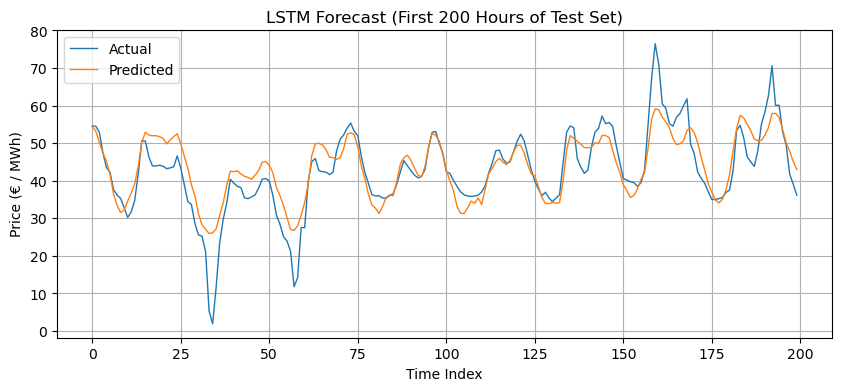

In [71]:
# Plot predicted vs actual
plt.figure(figsize=(10,4))
plt.plot(y_true_inv[:200], label="Actual", linewidth=1)
plt.plot(y_pred_inv[:200], label="Predicted", linewidth=1)
plt.title("LSTM Forecast (First 200 Hours of Test Set)")
plt.xlabel("Time Index")
plt.ylabel("Price (€ / MWh)")
plt.legend()
plt.grid(True)
plt.show()

## Optuna

In [75]:
import os, sys, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import optuna

In [ ]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu


In [ ]:

og_columns = [
    'precipitation', 'cloud_cover', 'temperature', 'relative_humidity',
    'load', 'sum_cbet', 'price'
]

df = pd.read_csv("./data/raw/dataset_2019_2025.csv")
df = df[['datetime'] + og_columns].copy()
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime')

# Clean invalid rows
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="any")

# Restrict to one year for tuning speed
df = df.loc["2019-01-03":"2019-12-31"]
print("Data size after cleaning:", df.shape)

Data size after cleaning: (8712, 7)


In [ ]:
# Add cyclical time features
df["hour_sin"]  = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df.index.hour / 24)
df["dow_sin"]   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)

# Split X / y
y_all = df["price"].astype(float)
X_all = df.drop(columns=["price"]).astype(float)

# Train-test split
N = len(df)
n_test = int(np.ceil(0.10 * N))
n_trainval = N - n_test

X_trainval = X_all.iloc[:n_trainval].copy()
y_trainval = y_all.iloc[:n_trainval].copy()
X_test = X_all.iloc[n_trainval:].copy()
y_test = y_all.iloc[n_trainval:].copy()

# Standard scaler
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_trainval_scaled = x_scaler.fit_transform(X_trainval)
y_trainval_scaled = y_scaler.fit_transform(y_trainval.to_numpy().reshape(-1, 1)).reshape(-1)
X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1, 1)).reshape(-1)

print("Scaled shapes:", X_trainval_scaled.shape, y_trainval_scaled.shape)


Scaled shapes: (7840, 12) (7840,)


In [ ]:
# Model def
class SequenceDataset(Dataset):
    def __init__(self, X_array, y_array, seq_len: int):
        X_array = np.asarray(X_array, dtype=np.float32)
        y_array = np.asarray(y_array, dtype=np.float32).reshape(-1)
        self.X, self.y, self.seq_len = X_array, y_array, int(seq_len)
        self.length = len(self.y) - self.seq_len
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        x_seq = self.X[idx:idx+self.seq_len]
        y_t = self.y[idx+self.seq_len]
        return torch.from_numpy(x_seq), torch.tensor(y_t, dtype=torch.float32)

def make_loader(X, y, seq_len: int, batch_size: int, shuffle: bool=False):
    ds = SequenceDataset(X, y, seq_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

class LSTMRegressor(nn.Module):
    def __init__(self, n_features: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        y_pred = self.fc(last_hidden)
        return y_pred.squeeze(-1)



In [ ]:

def train_model(X_tr, y_tr, X_va, y_va, seq_len, model_params, max_epochs=40, patience=5):
    n_features = X_tr.shape[1]
    model = LSTMRegressor(
        n_features=n_features,
        hidden_size=model_params["hidden_size"],
        num_layers=model_params["num_layers"],
        dropout=model_params["dropout"]
    ).to(DEVICE)

    train_loader = make_loader(X_tr, y_tr, seq_len, model_params["batch_size"])
    val_loader = make_loader(X_va, y_va, seq_len, model_params["batch_size"])

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=model_params["lr"])
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                y_pred = model(xb)
                loss = criterion(y_pred, yb)
                val_loss += loss.item() * len(xb)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return best_val_loss


In [ ]:
# optuna function
def objective(trial):
    # Hyperparameters to search
    params = {
        "hidden_size": trial.suggest_int("hidden_size", 32, 128, step=32),
        "num_layers": trial.suggest_int("num_layers", 1, 3),
        "dropout": trial.suggest_float("dropout", 0.0, 0.4),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
    }

    seq_len = trial.suggest_int("seq_len", 24, 72, step=24)

    # Split train/val
    cut = int(len(X_trainval_scaled) * 0.8)
    X_tr, X_va = X_trainval_scaled[:cut], X_trainval_scaled[cut:]
    y_tr, y_va = y_trainval_scaled[:cut], y_trainval_scaled[cut:]

    val_loss = train_model(X_tr, y_tr, X_va, y_va, seq_len, params)
    return val_loss

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, timeout=1800)  

print("\nBest parameters:")
print(study.best_params)
print("Best validation loss:", study.best_value)

[I 2025-11-03 00:01:40,135] A new study created in memory with name: no-name-4c8f1e73-bee4-4a32-9454-5ae3ff64bcf8
[I 2025-11-03 00:01:52,167] Trial 0 finished with value: 0.2751048565335533 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.08295689497439392, 'lr': 0.000655557114335162, 'batch_size': 128, 'seq_len': 24}. Best is trial 0 with value: 0.2751048565335533.
[I 2025-11-03 00:01:59,282] Trial 1 finished with value: 0.3280484596064671 and parameters: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.23313540999910984, 'lr': 0.0006005070975400105, 'batch_size': 128, 'seq_len': 24}. Best is trial 0 with value: 0.2751048565335533.
[I 2025-11-03 00:03:03,313] Trial 2 finished with value: 0.3229445844811479 and parameters: {'hidden_size': 96, 'num_layers': 3, 'dropout': 0.03429139854979853, 'lr': 0.00023949318646785268, 'batch_size': 128, 'seq_len': 24}. Best is trial 0 with value: 0.2751048565335533.
[I 2025-11-03 00:03:15,474] Trial 3 finished with value: 0.27294317


Best parameters:
{'hidden_size': 64, 'num_layers': 3, 'dropout': 0.21489492411799005, 'lr': 0.001544964575368075, 'batch_size': 32, 'seq_len': 24}
Best validation loss: 0.2264503755177241


In [ ]:
best_params = study.best_params
seq_len = best_params["seq_len"]

cut = int(len(X_trainval_scaled) * 0.8)
X_tr, X_va = X_trainval_scaled[:cut], X_trainval_scaled[cut:]
y_tr, y_va = y_trainval_scaled[:cut], y_trainval_scaled[cut:]

train_model(X_tr, y_tr, X_va, y_va, seq_len, best_params) 
final_model = LSTMRegressor(
    n_features=X_tr.shape[1],
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"]
).to(DEVICE)


train_model(X_trainval_scaled, y_trainval_scaled, X_test_scaled, y_test_scaled, seq_len, best_params)


0.6081203977524672

In [ ]:
# Evaluate
test_loader = make_loader(X_test_scaled, y_test_scaled, seq_len, best_params["batch_size"])
final_model.eval()
preds, actuals = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = final_model(xb)
        preds.extend(out.cpu().numpy().flatten())
        actuals.extend(yb.cpu().numpy().flatten())

preds = np.array(preds)
actuals = np.array(actuals)
y_pred_inv = y_scaler.inverse_transform(preds.reshape(-1,1)).flatten()
y_true_inv = y_scaler.inverse_transform(actuals.reshape(-1,1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

print("\nFinal LSTM Test Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


Final LSTM Test Evaluation:
RMSE: 16.8250
MAE:  11.0122
R²:   -0.0600


In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_true_inv[:200], label="Actual", linewidth=1)
plt.plot(y_pred_inv[:200], label="Predicted", linewidth=1)
plt.title("LSTM Forecast (First 200 Hours of Test Set)")
plt.xlabel("Time Index")
plt.ylabel("Price (€ / MWh)")
plt.legend()
plt.grid(True)
plt.show()